 Working Directory: /content
Loading and processing dataset...
    Injecting noise x 5 versions...

 RUNNING DETERMINISTIC BASELINES...

 RUNNING RANDOM WALK BASELINE (48 Random Prompts)...
    Random Prompt 1/48: Acc 0.0%
    Random Prompt 2/48: Acc 10.0%
    Random Prompt 3/48: Acc 0.0%
    Random Prompt 4/48: Acc 40.0%
    Random Prompt 5/48: Acc 0.0%
    Random Prompt 6/48: Acc 10.0%
    Random Prompt 7/48: Acc 35.0%
    Random Prompt 8/48: Acc 0.0%
    Random Prompt 9/48: Acc 15.0%
    Random Prompt 10/48: Acc 40.0%
    Random Prompt 11/48: Acc 0.0%
    Random Prompt 12/48: Acc 5.0%
    Random Prompt 13/48: Acc 0.0%
    Random Prompt 14/48: Acc 35.0%
    Random Prompt 15/48: Acc 10.0%
    Random Prompt 16/48: Acc 15.0%
    Random Prompt 17/48: Acc 5.0%
    Random Prompt 18/48: Acc 15.0%
    Random Prompt 19/48: Acc 0.0%
    Random Prompt 20/48: Acc 0.0%
    Random Prompt 21/48: Acc 0.0%
    Random Prompt 22/48: Acc 45.0%
    Random Prompt 23/48: Acc 70.0%
    Random Prompt 24/48: 

Random Search: 100%|██████████| 168/168 [01:24<00:00,  1.99it/s]


FINAL RESULTS TABLE (For Chapter 4)
1. Chain-of-Thought:  18.00% (±5.8%)
2. Random Search:     54.76% (±7.5%)
3. Zero-Shot:         54.00% (±7.5%)
4. Evolutionary (GA): 61.31% (±7.4%)


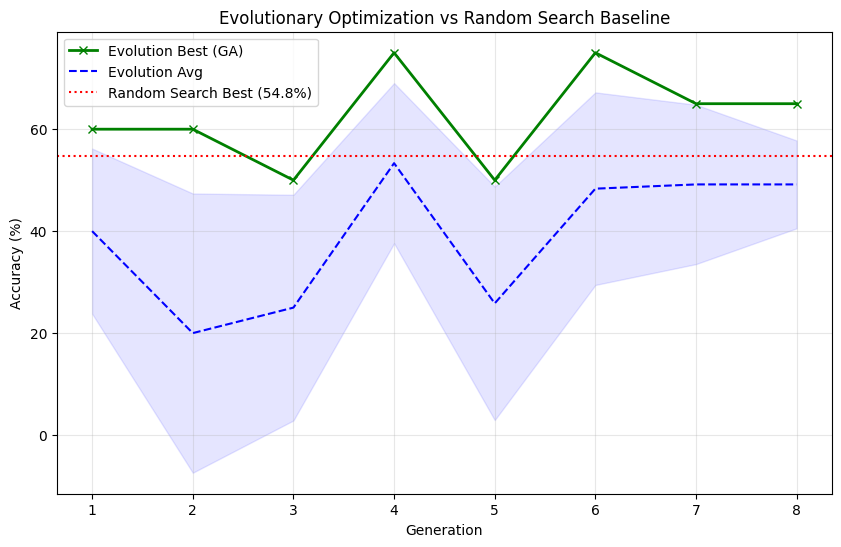

In [ ]:
!pip install rapidfuzz
import pandas as pd
import openai
import random
import csv
import time
import os
import string
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from rapidfuzz import fuzz

# ================= CONFIGURATION =================
os.environ["OPENAI_API_KEY"] = "use your own api key"
client = openai.OpenAI()

# Experiment Settings
GENERATIONS = 8
POPULATION_SIZE = 6
ELITISM = 2
TOTAL_EVALUATIONS = GENERATIONS * POPULATION_SIZE # For fair Random Search comparison

#  DATA AUGMENTATION
AUGMENTATION_FACTOR = 5
TEST_ROWS = 20

# Files
SOURCE_DATA = "restaurants.csv"
LOG_FILE = "evolution_log.csv"

print(f" Working Directory: {os.getcwd()}")

# ================= PART 1: HELPER FUNCTIONS =================

def make_harder(text):
    """Injects synthetic noise."""
    if not isinstance(text, str): return str(text)
    if random.random() > 0.6: # Typo
        if len(text) > 1:
            idx = random.randint(0, len(text)-1)
            text = text[:idx] + text[idx+1:]
    if random.random() > 0.7: # Case Swap
        text = text.swapcase()
    if random.random() > 0.8: # OCR Noise
        text += "".join(random.choices(string.ascii_uppercase + string.digits, k=2))
    return text

def load_and_process_data(filename):
    print("Loading and processing dataset...")
    if not os.path.exists(filename): return None, None
    try: df = pd.read_csv(filename)
    except: return None, None

    dirty_list, clean_list = [], []
    print(f"    Injecting noise x {AUGMENTATION_FACTOR} versions...")

    for cluster_id, group in df.groupby("cluster"):
        if len(group) >= 2:
            sorted_group = group.sort_values(by="name", key=lambda x: x.str.len(), ascending=False)
            clean_entry = sorted_group.iloc[0]
            for i in range(1, len(sorted_group)):
                dirty_entry = sorted_group.iloc[i]
                for _ in range(AUGMENTATION_FACTOR):
                    dirty_name = make_harder(dirty_entry['name'])
                    dirty_addr = make_harder(dirty_entry['address'])
                    dirty_list.append(f"Nm: {dirty_name} | Ad: {dirty_addr} | Ci: {dirty_entry['city']}")
                    clean_list.append(f"Name: {clean_entry['name']}, Addr: {clean_entry['address']}, City: {clean_entry['city']}")

    full_df = pd.DataFrame({"dirty": dirty_list, "clean": clean_list})
    full_df = full_df.sample(frac=1).reset_index(drop=True)
    train_size = int(0.7 * len(full_df))
    return full_df.iloc[:train_size].reset_index(drop=True), full_df.iloc[train_size:].reset_index(drop=True)

def get_llm_response(prompt, dirty_input):
    try:
        completion = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "system", "content": prompt},
                      {"role": "user", "content": f"Standardize this restaurant record to the official format: {dirty_input}"}],
            temperature=0.0, max_tokens=100)
        return completion.choices[0].message.content.strip(), completion.usage.total_tokens
    except: return "ERROR", 0

def calculate_score(ground_truth, llm_output):
    truth_norm = ground_truth.lower().strip()
    output_norm = llm_output.lower().strip()
    if truth_norm in output_norm: return 1.0
    if fuzz.token_set_ratio(truth_norm, output_norm) > 85: return 1.0
    return 0.0

def calculate_ci(accuracy, n):
    if n == 0: return 0.0
    return 1.96 * math.sqrt((accuracy * (1 - accuracy)) / n) * 100

def mutate_prompt(parent_prompt):
    try:
        completion = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": f"Rewrite this data cleaning prompt to be more robust to OCR errors. Prompt: '{parent_prompt}'"}])
        return completion.choices[0].message.content.strip().replace('"', '')
    except: return parent_prompt

# --- NEW: RANDOM SEARCH BASELINE ---
def run_random_search(train_df):
    print(f"\n RUNNING RANDOM WALK BASELINE ({TOTAL_EVALUATIONS} Random Prompts)...")
    best_acc = 0
    best_prompt = ""

    # Generate N random prompts using GPT-4o
    for i in range(TOTAL_EVALUATIONS):
        try:
            completion = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": "Generate a unique, single-sentence system prompt for an AI to clean dirty restaurant data."}],
                temperature=1.0 # High temp for diversity
            )
            prompt = completion.choices[0].message.content.strip().replace('"', '')
        except: continue

        # Test on small batch
        sample = train_df.sample(n=TEST_ROWS)
        score = 0
        for _, row in sample.iterrows():
            out, _ = get_llm_response(prompt, row['dirty'])
            score += calculate_score(row['clean'], out)

        acc = score / TEST_ROWS
        if acc > best_acc:
            best_acc = acc
            best_prompt = prompt

        print(f"    Random Prompt {i+1}/{TOTAL_EVALUATIONS}: Acc {acc*100:.1f}%")

    print(f"    Best Random Prompt Accuracy: {best_acc*100:.2f}%")
    return best_prompt, best_acc

# ================= PART 2: MAIN EXECUTION =================

train_df, test_df = load_and_process_data(SOURCE_DATA)

if train_df is not None:
    # 1. Baselines (Deterministic)
    print("\n RUNNING DETERMINISTIC BASELINES...")
    # Zero Shot
    zs_score = 0
    sample = test_df.sample(n=min(50, len(test_df)))
    for _, row in sample.iterrows():
        out, _ = get_llm_response("Fix the restaurant data formatting.", row['dirty'])
        zs_score += calculate_score(row['clean'], out)
    acc_zero = zs_score / len(sample)

    # CoT
    cot_score = 0
    for _, row in sample.iterrows():
        out, _ = get_llm_response("Step 1: Identify entity. Step 2: Standardize. Step 3: Output clean version.", row['dirty'])
        cot_score += calculate_score(row['clean'], out)
    acc_cot = cot_score / len(sample)

    # 2. Random Walk Baseline
    random_best_prompt, random_train_acc = run_random_search(train_df)

    # 3. Evolutionary Algorithm
    print(f"\n STARTING EVOLUTION...")
    current_population = ["You are a data cleaner.", "Fix the formatting.", "Standardize the record.", "Correct typos.", "Output official format."]

    with open(LOG_FILE, 'w', newline='') as f:
        csv.writer(f).writerow(["Generation", "Prompt", "Accuracy", "Avg_Tokens"])

    top_prompts = []
    for gen in range(GENERATIONS):
        print(f"--- Gen {gen+1} ---")
        scores = []
        for prompt in current_population:
            batch_score = 0
            sample = train_df.sample(n=TEST_ROWS)
            for _, row in sample.iterrows():
                out, _ = get_llm_response(prompt, row['dirty'])
                batch_score += calculate_score(row['clean'], out)

            avg_acc = batch_score / TEST_ROWS
            scores.append((prompt, avg_acc))
            with open(LOG_FILE, 'a', newline='') as f:
                csv.writer(f).writerow([gen+1, prompt, avg_acc, 0])

        scores.sort(key=lambda x: x[1], reverse=True)
        top_prompts = [x[0] for x in scores[:ELITISM]]
        print(f"    Leader: {scores[0][1]*100:.1f}%")

        next_gen = top_prompts[:]
        while len(next_gen) < POPULATION_SIZE:
            next_gen.append(mutate_prompt(random.choice(top_prompts)))
        current_population = next_gen

    # 4. FINAL EXAM (All Methods on Test Set)
    print(f"\n FINAL EXAM ({len(test_df)} rows)...")

    def evaluate_on_test(prompt, name):
        score = 0
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=name):
            out, _ = get_llm_response(prompt, row['dirty'])
            score += calculate_score(row['clean'], out)
        return score / len(test_df)

    final_acc_evo = evaluate_on_test(top_prompts[0], "Evolutionary")
    final_acc_rand = evaluate_on_test(random_best_prompt, "Random Search")

    # CI Calcs
    n = len(test_df)
    ci_evo = calculate_ci(final_acc_evo, n)
    ci_rand = calculate_ci(final_acc_rand, n)
    ci_zero = calculate_ci(acc_zero, n) # Using estimated acc for zero/cot on full set
    ci_cot = calculate_ci(acc_cot, n)

    print("="*50)
    print("FINAL RESULTS TABLE (For Chapter 4)")
    print("="*50)
    print(f"1. Chain-of-Thought:  {acc_cot*100:.2f}% (±{ci_cot:.1f}%)")
    print(f"2. Random Search:     {final_acc_rand*100:.2f}% (±{ci_rand:.1f}%)")
    print(f"3. Zero-Shot:         {acc_zero*100:.2f}% (±{ci_zero:.1f}%)")
    print(f"4. Evolutionary (GA): {final_acc_evo*100:.2f}% (±{ci_evo:.1f}%)")
    print("="*50)

    # 5. Graphing
    log_df = pd.read_csv(LOG_FILE)
    stats = log_df.groupby("Generation")["Accuracy"].agg(['mean', 'max', 'std']) * 100

    plt.figure(figsize=(10, 6))
    plt.plot(stats.index, stats["max"], label="Evolution Best (GA)", color="green", marker="x", linewidth=2)
    plt.plot(stats.index, stats["mean"], label="Evolution Avg", color="blue", linestyle="--")
    plt.fill_between(stats.index, stats["mean"]-stats["std"], stats["mean"]+stats["std"], color="blue", alpha=0.1)

    # Add Random Baseline Line
    plt.axhline(y=final_acc_rand*100, color='red', linestyle=':', label=f"Random Search Best ({final_acc_rand*100:.1f}%)")

    plt.title("Evolutionary Optimization vs Random Search Baseline")
    plt.xlabel("Generation")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("final_results_with_random_baseline.png", dpi=300)
    plt.show()